# GRADIENT DESCENT FAILURE MODES:
### An Experimental Study of Stability, Convergence, and Optimization Dynamics

---

## Project Overview
These experiment investigates  **how** and **why** neural networks fail during training under different optimization conditions.

Instead of focusing on accuracy, the objective is to expose **failure modes** such as:
- Divergence
- Oscillation
- Vanishing gradients
- Symmetry collapse
- Grdient explosion

Through controlled experiments, this project analyzes how learning rate, initialization, activation functions, and feature scaling affect training dynamics.

---


## Hypothesis
- Increasing learning rate beyond a threshold will cause divergence.
- Zero initialization will prevent learning due to symmetry.
- Sigmoid activation will lead to vanishing gradients.
- Poor feature scaling will destabilize optimization.
- proper normalization will restore stable convergence.


## Tools & Justification:

* Numpy/PyTorch - full control over gradients and updates
* Matplotlib- visualize convergence and instability
* Synthetic dataset- eliminate noise and isolate optimization behaviour


---


## Objectives:

- Identify when training fails and why.
- Visualize convergence vs divergence patterns.
- Build intuition for optimization dynamics in neural networks.

## Experimental Setup

### Dataset:

I'm going to use a simple synthetic regression dataset

- Input: values between -1 and 1
- Output: linear function with noise

This allow us to isolate optimization effects without real-world complexity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(-1, 1, 100).reshape(-1, 1)
y = 3 * X + 0.5 * np.random.randn(100, 1)

## Model Architecture

Implement a simple 2-layer neural network:

Input---> Hidden Layer(ReLU/sigmoid) ---> Output

- Hidden layer: 10 neurons
- Activation: ReLU or Sigmoid
- Loss: Mean Squared Error or BCE(classification)

the simplicity ensures that observed failures are due to optimization not model complexity.


### Metrics

- Loss vs epochs
- Weight updates
- Gradient magnitude

In [ ]:
class SimpleNN:
    def __init__(self, activation='relu', init='random'):
        if init == 'zero':
            self.W1 = np.zeros((1, 10))
            self.W2 = np.zeros((10, 1))
        else:
            self.W1 = np.random.randn(1, 10) * 0.5
            self.W2 = np.random.randn(10, 1) * 0.5

        self.activation = activation

    def forward(self, X):
        self.Z1 = X @ self.W1
        if self.activation == 'relu':
            self.A1 = np.maximum(0, self.Z1)
        else:
            self.A1 = 1 / (1 + np.exp(-self.Z1))
        self.Z2 = self.A1 @ self.W2
        return self.Z2

    def backward(self, X, y, lr):
        m = len(X)
        dZ2 = (self.Z2 - y) / m
        dW2 = self.A1.T @ dZ2

        if self.activation == 'relu':
            dA1 = dZ2 @ self.W2.T * (self.Z1 > 0)
        else:
            s = 1 / (1 + np.exp(-self.Z1))
            dA1 = dZ2 @ self.W2.T * s * (1 - s)

        dW1 = X.T @ dA1

        grad_norm = np.linalg.norm(dW1) + np.linalg.norm(dW2)

        self.W1 -= lr * dW1
        self.W2 -= lr * dW2

        return grad_norm

    def train(self, X, y, lr=0.01, epochs=200):
        losses = []
        grads = []

        for i in range(epochs):
            preds = self.forward(X)
            loss = np.mean((preds - y) ** 2)

            if np.isnan(loss) or loss > 1e6:
                print(f"DIVERGED at epoch {i}")
                break

            grad_norm = self.backward(X, y, lr)

            losses.append(loss)
            grads.append(grad_norm)

        return losses, grads

# Experiments

## Experiment 1 — Learning Rate Sensitivity

### Hypothesis
Learning rate directly controls stability:
- Too small → slow convergence  
- Optimal/medium LR → smooth convergence  
- Too large → divergence  

### Procedure
Train the same model with different learning rates.

DIVERGED at epoch 2


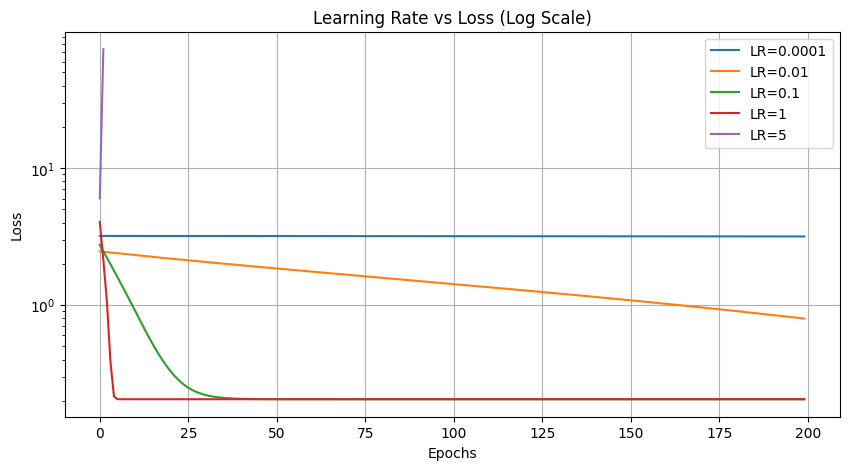

In [ ]:
lrs = [0.0001, 0.01, 0.1, 1, 5]

plt.figure(figsize=(10,5))

for lr in lrs:
    model = SimpleNN()
    losses, _ = model.train(X, y, lr=lr, epochs=200)

    plt.plot(losses, label=f"LR={lr}")

plt.yscale('log')
plt.title("Learning Rate vs Loss (Log Scale)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Gradient Plot:

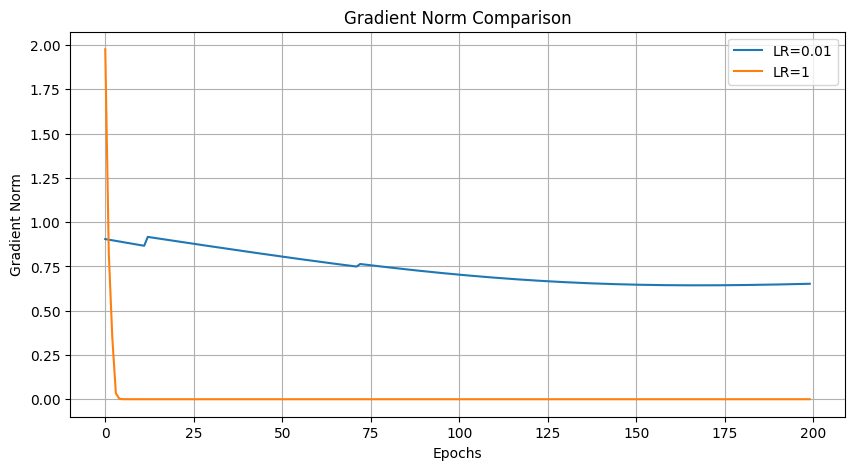

In [ ]:
plt.figure(figsize=(10,5))

for lr in [0.01, 1]:
    model = SimpleNN()
    _, grads = model.train(X, y, lr=lr, epochs=200)

    plt.plot(grads, label=f"LR={lr}")

plt.title("Gradient Norm Comparison")
plt.xlabel("Epochs")
plt.ylabel("Gradient Norm")
plt.legend()
plt.grid()
plt.show()

### Observed Behaviour:

- Very Low LR: slow, steady decline
- Medium LR: fastest convergence  
- High LR: unstable or exploding loss

## Experiment 2 — Initialization Failure

### Hypothesis
Zero initialization prevents symmetry breaking, stopping learning.

### Procedure
Compare zero vs random initialization (all weights = 0 --> random small values)

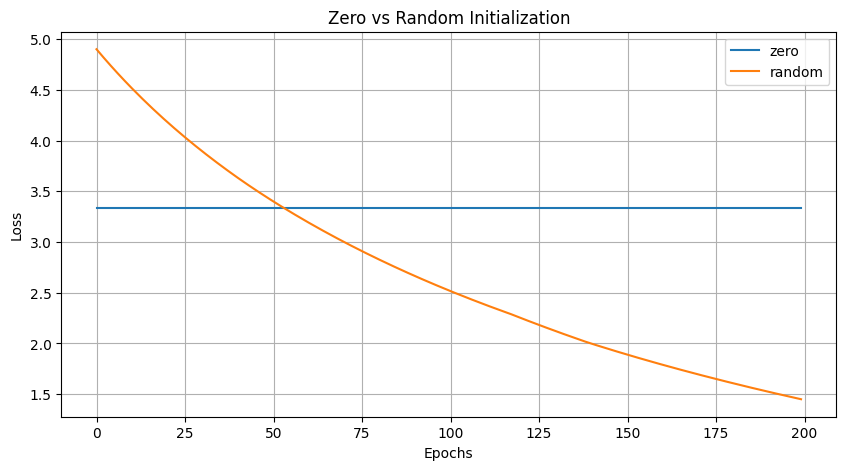

In [ ]:
configs = ['zero', 'random']

plt.figure(figsize=(10,5))

for init in configs:
    model = SimpleNN(init=init)
    losses, _ = model.train(X, y, lr=0.01)

    plt.plot(losses, label=f"{init}")

plt.title("Zero vs Random Initialization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

### Observation

- Zero initialization → flat loss (no learning)
- Random initialization → proper convergence (learning starts)


## Experiment 3 — Activation Function Impact

### Hypothesis
Sigmoid causes slower learning due to vanishing gradients

ReLU --> faster convergence

### Procedure
Comapre ReLU vs Sigmoid

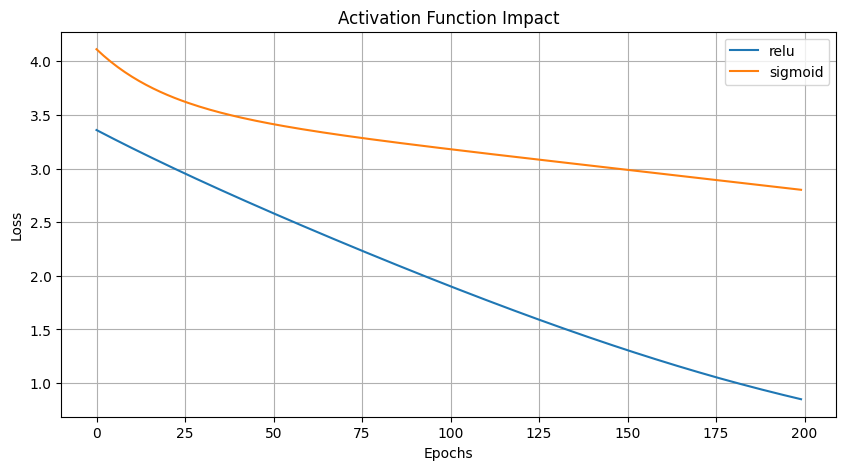

In [ ]:
acts = ['relu', 'sigmoid']

plt.figure(figsize=(10,5))

for act in acts:
    model = SimpleNN(activation=act)
    losses, _ = model.train(X, y, lr=0.01)

    plt.plot(losses, label=f"{act}")

plt.title("Activation Function Impact")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

### Gradient Collapse Visualization

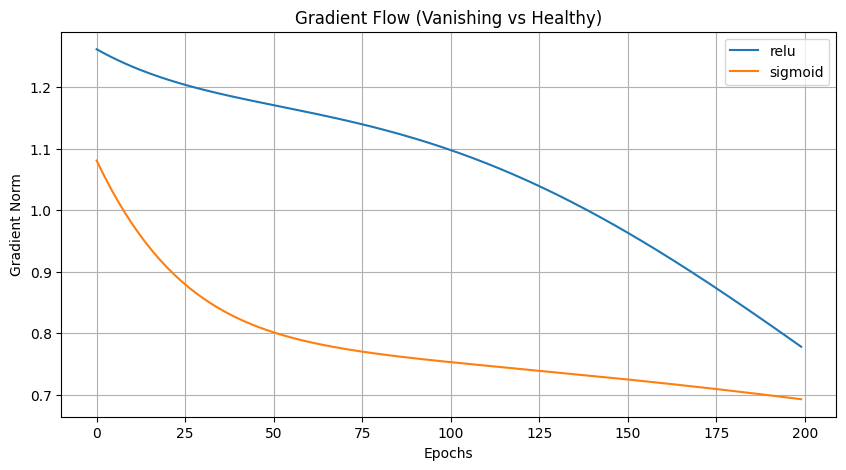

In [ ]:
plt.figure(figsize=(10,5))

for act in acts:
    model = SimpleNN(activation=act)
    _, grads = model.train(X, y, lr=0.01)

    plt.plot(grads, label=f"{act}")

plt.title("Gradient Flow (Vanishing vs Healthy)")
plt.xlabel("Epochs")
plt.ylabel("Gradient Norm")
plt.legend()
plt.grid()
plt.show()

### Observed Behaviour

- ReLU ---> faster convergence
- Sigmoid ---> slower, sometimes plateau


## Experiment 4 — Gradient Explosion / Instability

### Hypothesis
Poor Scaling + high learning rate --> unstable gradients.

### Procedure
Multiply inputs by large factor (ex- *1000)
 and train with normal LR , Scale inputs drastically

DIVERGED at epoch 1


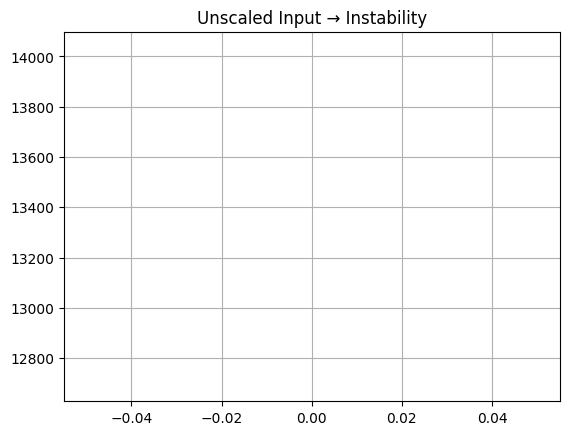

In [ ]:
X_bad = X * 1000

model = SimpleNN()
loss_bad, _ = model.train(X_bad, y, lr=0.01)

plt.plot(loss_bad)
plt.title("Unscaled Input → Instability")
plt.grid()
plt.show()

### Observed behaviour

- Loss explodes or becomes unstable
- Training fails to converge
- Gradient magnitude spikes

## Experiment 5 — Feature Scaling Fix

### Hypothesis
Normalization stabilizes optimization.

### Procedure
Normalize inputs and retrain (mean=o, std=1)

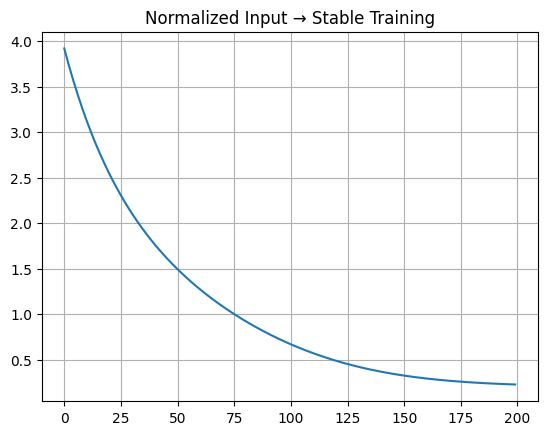

In [ ]:
X_fixed = (X_bad - X_bad.mean()) / X_bad.std()

model = SimpleNN()
loss_fixed, _ = model.train(X_fixed, y, lr=0.01)

plt.plot(loss_fixed)
plt.title("Normalized Input → Stable Training")
plt.grid()
plt.show()

### Observed Behaviour

- Stable convergence restored
- Loss decreases smoothly

## Direct Comparison

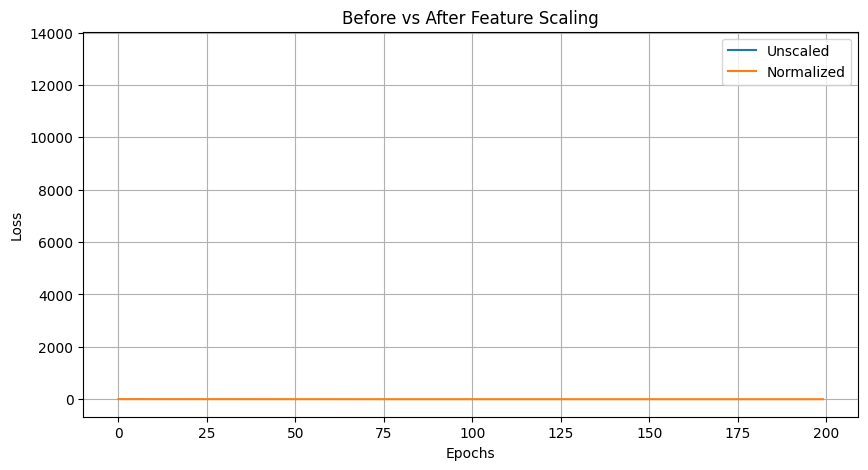

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(loss_bad, label="Unscaled")
plt.plot(loss_fixed, label="Normalized")

plt.title("Before vs After Feature Scaling")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

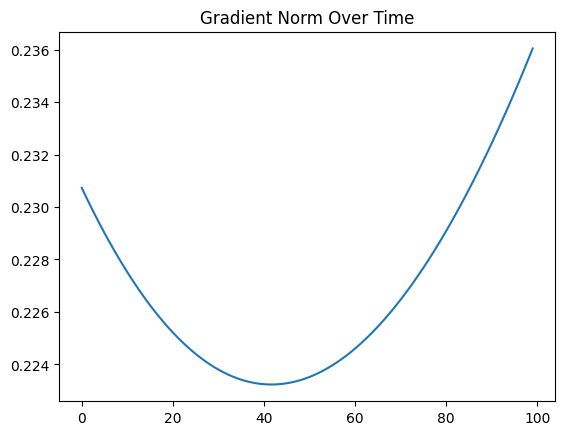

In [ ]:
# Gradient norm tracking (advanced insight)
def gradient_norm(model, X, y):
    model.forward(X)
    dZ2 = (model.Z2 - y) / len(X)
    dW2 = model.A1.T @ dZ2
    return np.linalg.norm(dW2)

model = SimpleNN()
norms = []

for _ in range(100):
    model.forward(X)
    norms.append(gradient_norm(model, X, y))
    model.backward(X, y, lr=0.01)

plt.plot(norms)
plt.title("Gradient Norm Over Time")
plt.show()

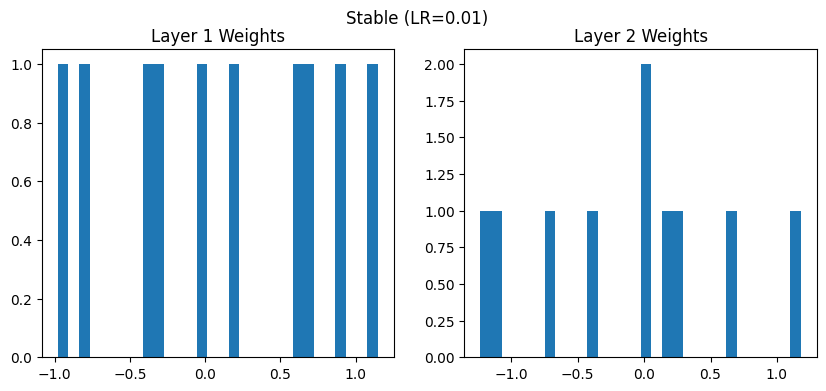

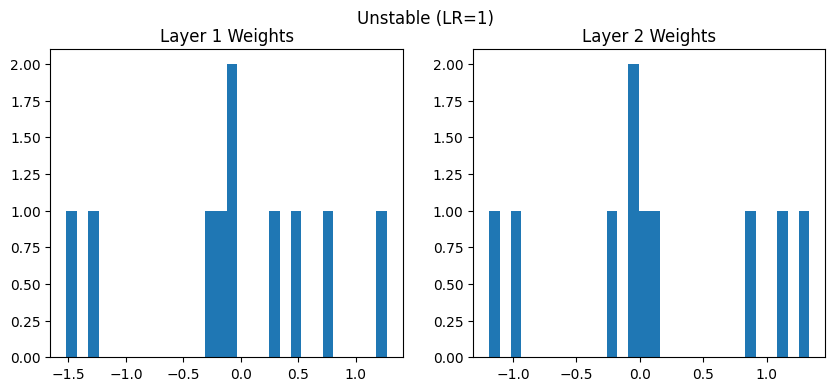

In [ ]:
# ===== WEIGHT DISTRIBUTION ANALYSIS =====

import matplotlib.pyplot as plt

def plot_weight_distribution(model, title="Weight Distribution"):
    W1 = model.W1.flatten()
    W2 = model.W2.flatten()

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(W1, bins=30)
    plt.title("Layer 1 Weights")

    plt.subplot(1,2,2)
    plt.hist(W2, bins=30)
    plt.title("Layer 2 Weights")

    plt.suptitle(title)
    plt.show()


# ===== RUN COMPARISON =====

configs = {
    "Stable (LR=0.01)": 0.01,
    "Unstable (LR=1)": 1
}

for name, lr in configs.items():
    model = SimpleNN()
    model.train(X, y, lr=lr, epochs=200)

    plot_weight_distribution(model, title=name)

- Stable training
weights centered, moderate spread
- High LR (unstable)
very wide spread OR extreme spikes
sometimes NaNs / broken distribution
- Collapsed learning (bad init)
weights barely move → narrow distribution

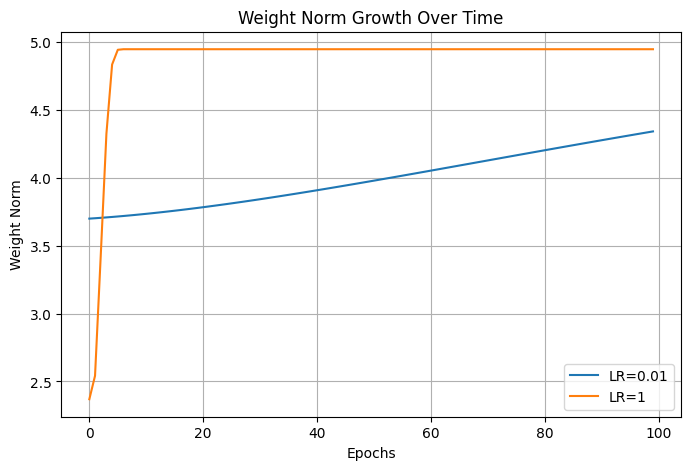

In [ ]:
# Track weight evolution over time

def track_weight_growth(lr):
    model = SimpleNN()
    norms = []

    for _ in range(100):
        model.forward(X)
        norm = np.linalg.norm(model.W1) + np.linalg.norm(model.W2)
        norms.append(norm)
        model.backward(X, y, lr)

    return norms


plt.figure(figsize=(8,5))

for lr in [0.01, 1]:
    norms = track_weight_growth(lr)
    plt.plot(norms, label=f"LR={lr}")

plt.title("Weight Norm Growth Over Time")
plt.xlabel("Epochs")
plt.ylabel("Weight Norm")
plt.legend()
plt.grid()
plt.show()

# Visual Evidence

All plots above demonstrates:
- Convergence vs divergence patterns
- Stability differences across configurations

---

# Failure Analysis

- High learning rates overshoot minima -> divergence
- Zero initialization prevents symmetry breaking -> identical neuron updates
- Sigmoid compresses gradients → slow learning
- Large feature scales amplify gradients -> instability  

# Key Insights:

- Optimization is highly sensitive to hyperparameters
- Training stability is not guaranteed, even in simple models
- Initialization determines whether learning starts
- Activation functions directly influence gradient flow  
- Feature scaling is a First-order effect

# Future Work

- Compare SGD vs Adam optimizer
- Extend to deeper networks  
- Visualize gradient norms explicitly  
- Analyze loss surface geometry
